In [1]:
import pandas as pd
import numpy as np

import sys
sys.path.append('..')

# Loading Data

In [2]:
clus_id = 5

In [3]:
labels = pd.read_csv(f"../data_in_processing/cluster_outputs/labels_{clus_id}.csv", index_col=[0, 1, 2, 3, 4, 5, 6])

labels

label
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5       
0       762         1316        1300        1264        1300        1272            -1
        1264        1316        1300        1264        1300        1272            -1
        1419        1316        1300        1264        1300        1272            -1
        1300        1316        1300        1264        1300        1272            -1
        1019        1316        1300        1264        1300        1272            -1
...                                                                                ...
251     1114        72          1053        1004        1052        1117            -1
        283         72          1053        1004        1052        1117            -1
        1114        283         72          2475        1052        1117            -1
                    72          2475        1004        399         1117            -1
                                1053        1004        399         1117            -1

[1738005 rows x 1 columns]

In [4]:
df_top_5 = pd.read_parquet(f"../data_in_processing/data_top5std.parquet")

df_top_5 = df_top_5.set_index(["image_T"] + [f"track_id_t{i}" for i in range(5+1)])

df_top_5

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1264        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1300        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.006720   
        283         72          1053        1004        1052        1117            0.006720   
        1114        283         72          2475        1052        1117           -0.006981   
                    72          2475        1004        399         1117            0.006720   
                                1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1264        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.026285   
        283         72          1053        1004        1052        1117            0.026285   
        1114        283         72          2475        1052        1117           -0.006943   
                    72          2475        1004        399         1117            0.017854   
                                1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1264        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1300        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117           -0.027770   
        283         72          1053        1004        1052        1117           -0.027770   
        1114        283         72          2475        1052        1117            0.011757   
                    72          2475        1004        399         1117           -0.027770   
                                1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1264        1316        1300        12

In [5]:
df = df_top_5.loc[::]

df["label"] = labels["label"]

df

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1264        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1300        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.006720   
        283         72          1053        1004        1052        1117            0.006720   
        1114        283         72          2475        1052        1117           -0.006981   
                    72          2475        1004        399         1117            0.006720   
                                1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1264        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.026285   
        283         72          1053        1004        1052        1117            0.026285   
        1114        283         72          2475        1052        1117           -0.006943   
                    72          2475        1004        399         1117            0.017854   
                                1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1264        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1300        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117           -0.027770   
        283         72          1053        1004        1052        1117           -0.027770   
        1114        283         72          2475        1052        1117            0.011757   
                    72          2475        1004        399         1117           -0.027770   
                                1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1264        1316        1300        12

# Visualizing Data

In [6]:
from scripts.Cluster_plotting import plot_all_columns, plot_hist

In [7]:
df["label"].value_counts()

label
-1      1652083
 92        4407
 91        2799
 112       1856
 146       1799
         ...   
 132        260
 94         260
 25         260
 90         256
 69         256
Name: count, Length: 168, dtype: int64

In [12]:
labels_selected=[lab for lab, lab_count in df["label"].value_counts().to_dict().items() if lab != -1 and lab_count>1100]

# labels_selected = [1, 2]

print(len(labels_selected))

8


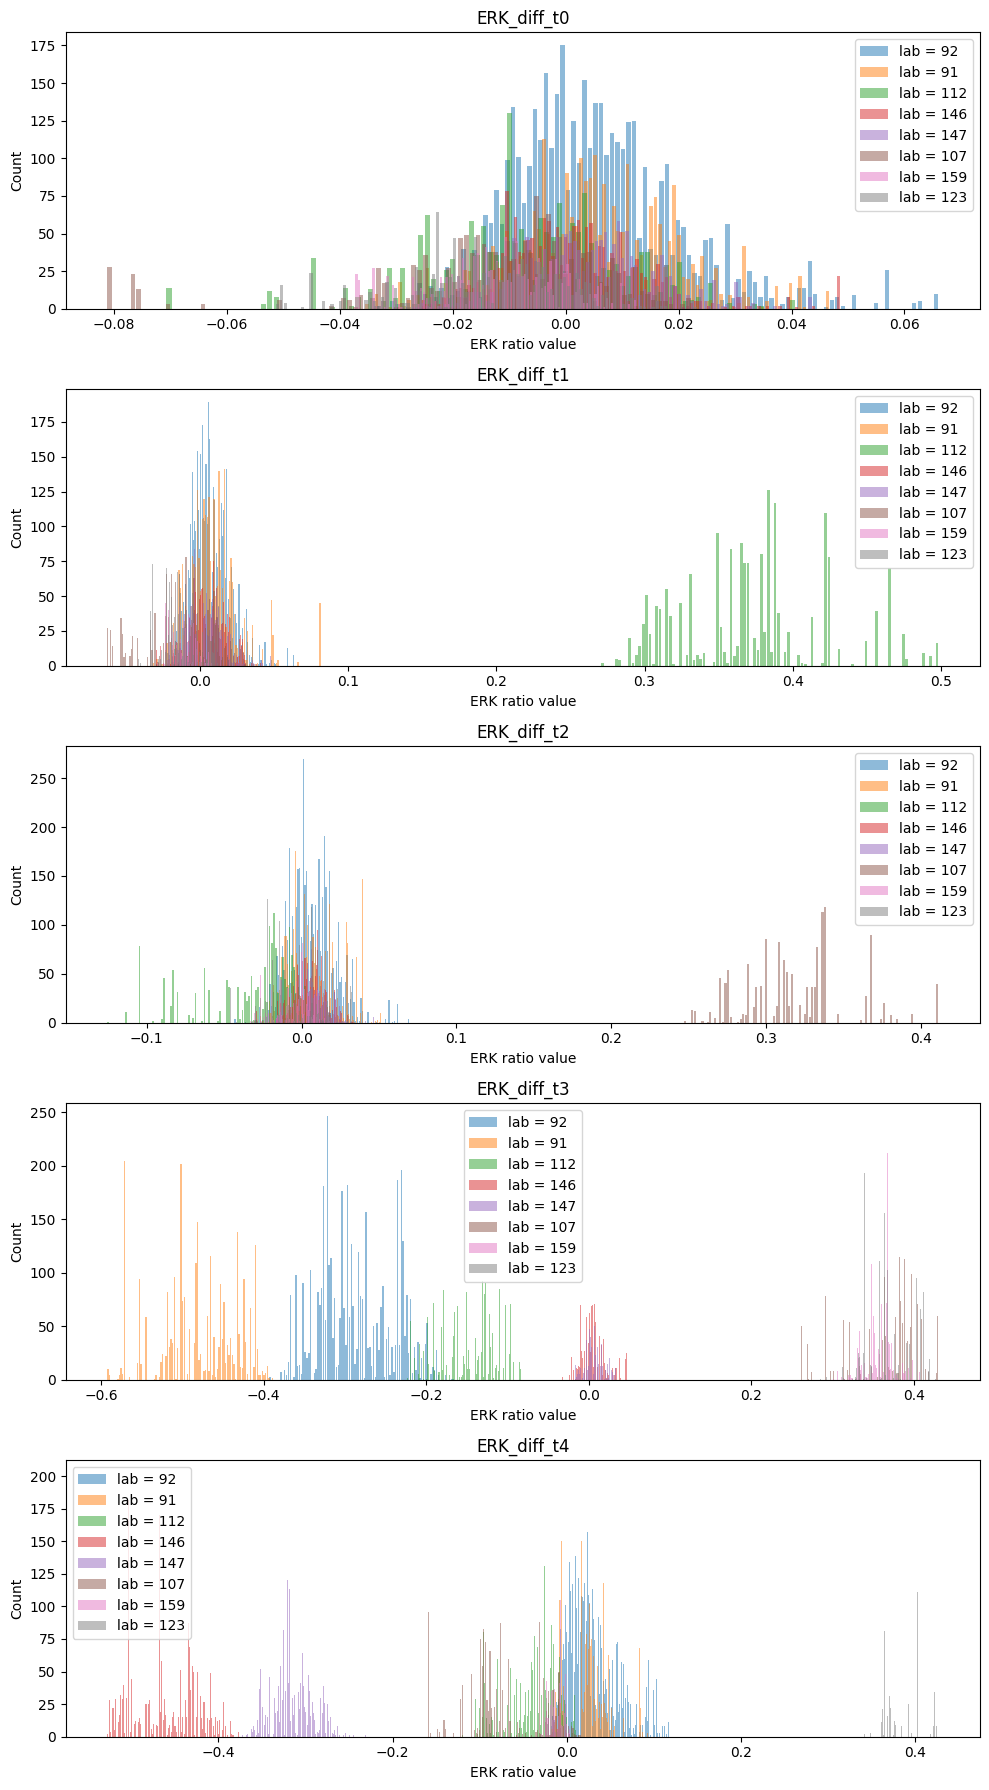

In [13]:
plot_hist(
    df=df,
    labels_selected=labels_selected,
    save_path=None
)

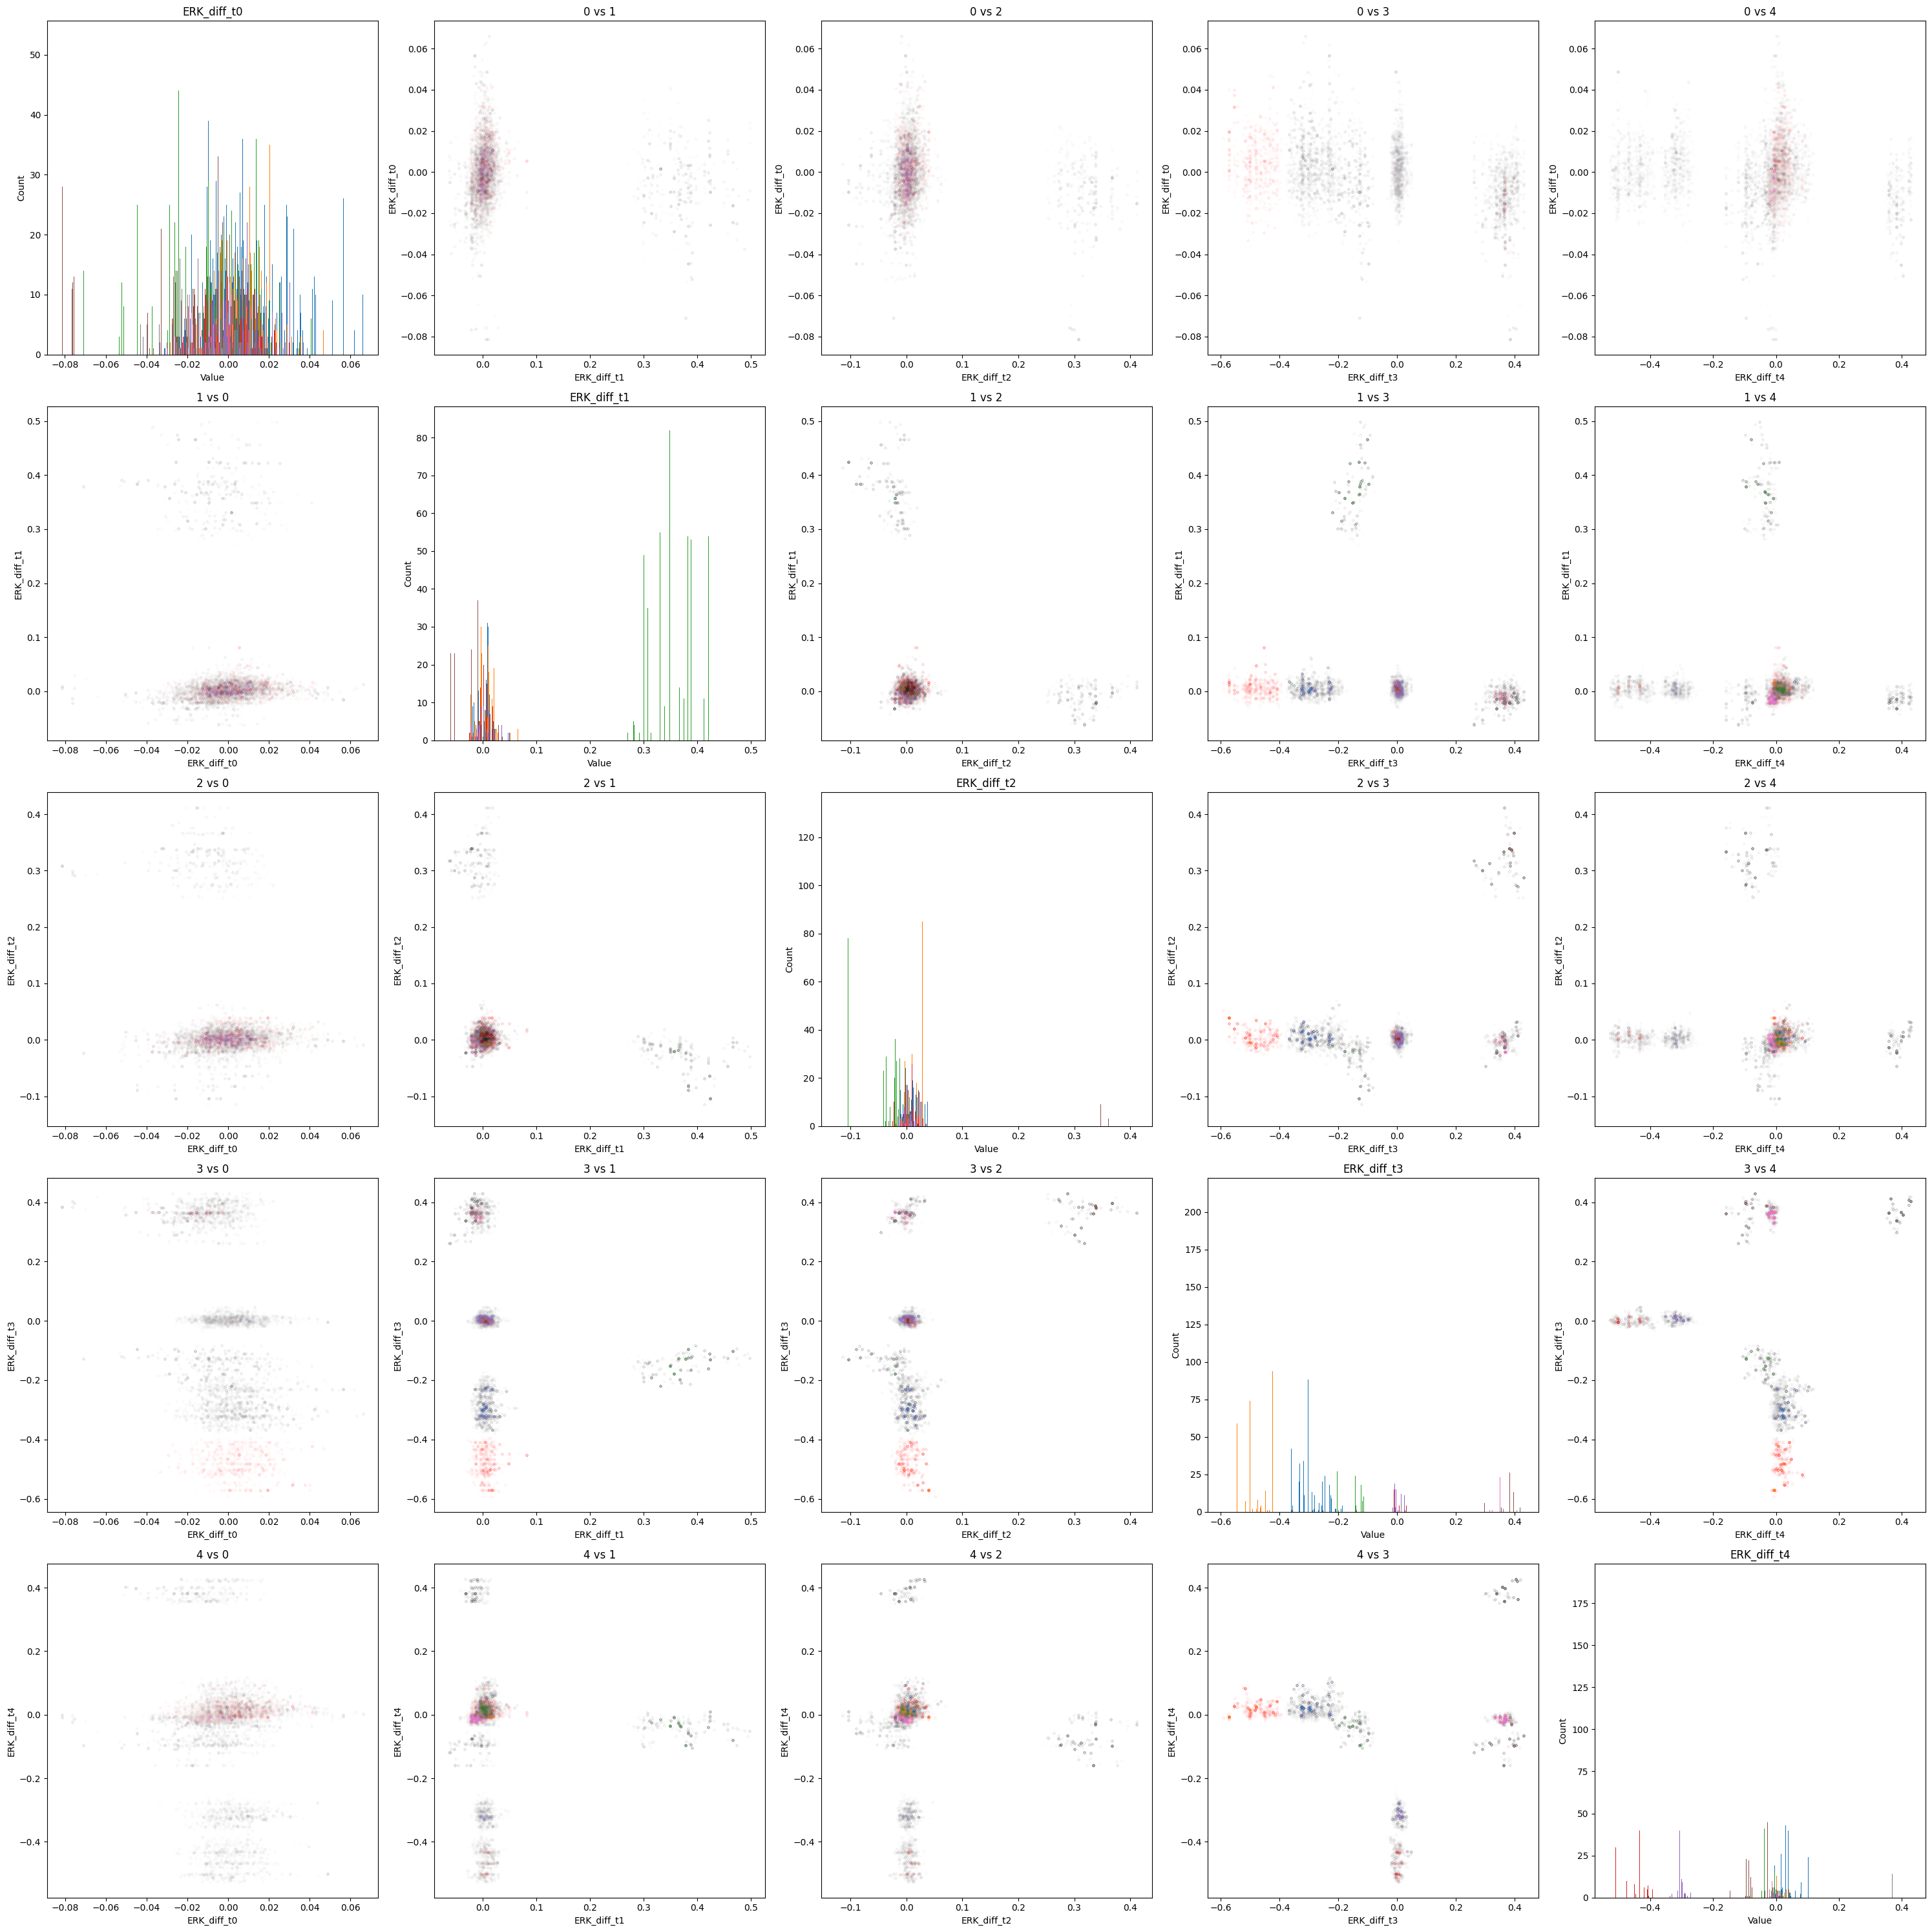

In [14]:
plot_all_columns(
    df.drop(columns="label"),
    df["label"],
    sel_labels=labels_selected,
    save_path=None
)